# Tutorial 6

Keep using the data in `AuQuGDP.csv`, which contains the Australia's quarterly GDP from 1960Q1 to 2020Q1, measured in 2007 Australian dollars and seasonally adjusted. 

**Note: the `AuGDP` series has come through with some rounded data that makes for the piece-wise looking time series. The methods are still correct, the underlying data is not. I don't have the original dataset to fix this so this will have to do.**

### Load Packages

In [62]:
%reset -f

import pandas            as pd
import matplotlib.pyplot as plt
import statsmodels.api   as sm
import seaborn           as sns
import numpy             as np

from scipy.stats                            import t
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from datetime                               import datetime
from statsmodels.tsa.stattools              import adfuller
from statsmodels.tsa.arima.model            import ARIMA

### Set Graph Parameters

In [63]:
pd.plotting.register_matplotlib_converters()
# Default figure size
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x) # makes numbas nice

# Q2

### Load Data

In [64]:
df = pd.read_csv("AuQuGDP.csv")

In [65]:
df.head()

,Unnamed: 0,Time,AuGDP,quarter,year,t
0,0,1/01/1960,64683000000.00,1,1960,1/01/1960
1,1,1/04/1960,66473000000.00,2,1960,1/04/1960
2,2,1/07/1960,66623000000.00,3,1960,1/07/1960
3,3,1/10/1960,66490000000.00,4,1960,1/10/1960
4,4,1/01/1961,66690000000.00,1,1961,1/01/1961


### Set Time Index

In [66]:
df['date'] = pd.to_datetime(df['Time'])
df = df.set_index('date')
df.drop(['Time'], axis = 1, inplace = True)
df.head()

,Unnamed: 0,AuGDP,quarter,year,t
date,,,,,
1960-01-01,0,64683000000.00,1,1960,1/01/1960
1960-01-04,1,66473000000.00,2,1960,1/04/1960
1960-01-07,2,66623000000.00,3,1960,1/07/1960
1960-01-10,3,66490000000.00,4,1960,1/10/1960
1961-01-01,4,66690000000.00,1,1961,1/01/1961


In [67]:
df = df.rename(columns={"AuGDP" : "Y"})

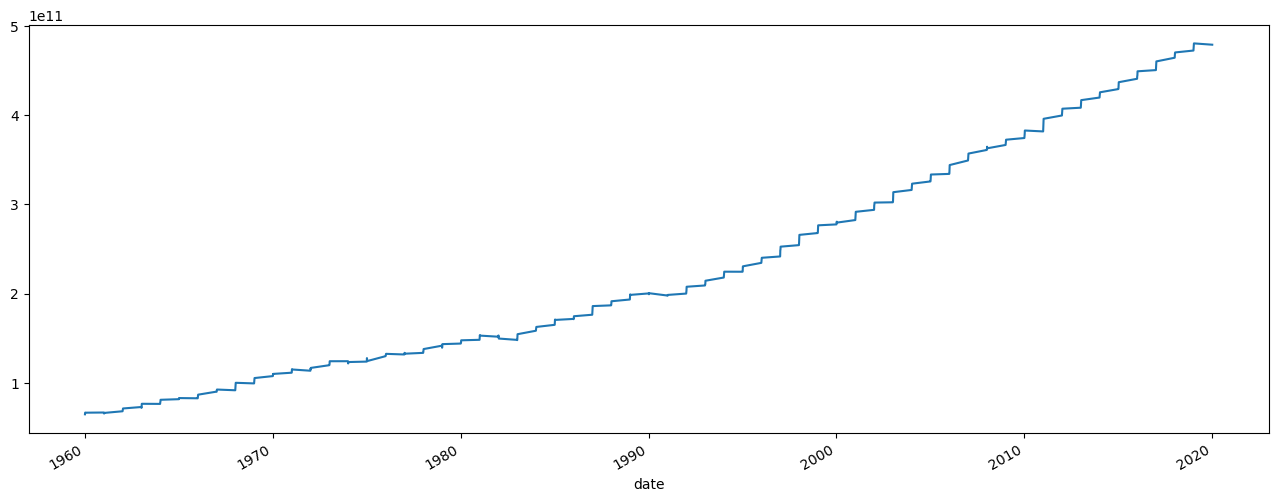

In [68]:
df['Y'].plot()
plt.show()

### (a). ADF
**Run the ADF test on the AuGDP series to test whether it is weakly stationary, trend stationary, or difference stationary.**

In [69]:
df2 = df

X = df['Y'].values

### ADF lag
result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -0.346, 
 p-value: 0.988, 
 critical value: {'1%': -3.9969944961660877, '5%': -3.4289434905960645, '10%': -3.1378930946180557}
 ADF statistic: -0.346, 
 p-value: 0.988, 
 critical value: {'1%': -3.9969944961660877, '5%': -3.4289434905960645, '10%': -3.1378930946180557}


### (b). Order of Intergration I(d)

**Use the ADF test to determine the order of I(d) for the AuGDP series so that we can model the series as an ARIMA(p,d,q) model.**

###### 1st Order Difference Test

In [70]:
df2['Y_D1'] = df2['Y'].diff()

df2 = df2.dropna(axis = 0)

X = df2['Y_D1'].values 

result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -15.258, 
 p-value: 0.000, 
 critical value: {'1%': -3.99715658668426, '5%': -3.4290213886201637, '10%': -3.137938763154836}
 ADF statistic: -15.258, 
 p-value: 0.000, 
 critical value: {'1%': -3.99715658668426, '5%': -3.4290213886201637, '10%': -3.137938763154836}


###### 2nd Order Difference Test

In [71]:
df2['Y_D2'] = df2['Y_D1'].diff()

df2 = df2.dropna(axis = 0)

X = df2['Y_D2'].values 

result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -13.022, 
 p-value: 0.000, 
 critical value: {'1%': -3.997818933858586, '5%': -3.4293396709977557, '10%': -3.13812535054853}
 ADF statistic: -12.140, 
 p-value: 0.000, 
 critical value: {'1%': -3.9979881078231756, '5%': -3.4294209574472734, '10%': -3.138173000968399}


###### 3rd Order Difference Test

In [72]:
df2['Y_D3'] = df2['Y_D2'].diff()

df2 = df2.dropna(axis = 0)

X = df2['Y_D3'].values 

result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -15.568, 
 p-value: 0.000, 
 critical value: {'1%': -3.9979881078231756, '5%': -3.4294209574472734, '10%': -3.138173000968399}
 ADF statistic: -10.687, 
 p-value: 0.000, 
 critical value: {'1%': -3.9990347583703216, '5%': -3.4299237913352556, '10%': -3.138467743111241}


###### 4th Order Difference Test

In [73]:
df2['Y_D2'] = df2['Y_D1'].diff()

df2 = df2.dropna(axis = 0)

X = df2['Y_D2'].values 

result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -12.969, 
 p-value: 0.000, 
 critical value: {'1%': -3.998158754122054, '5%': -3.429502948077832, '10%': -3.1382210632264758}
 ADF statistic: -12.073, 
 p-value: 0.000, 
 critical value: {'1%': -3.9983308920613543, '5%': -3.4295856520805996, '10%': -3.1382695426857397}


###### 5th Order Difference Test

In [74]:
df2['Y_D2'] = df2['Y_D1'].diff()

df2 = df2.dropna(axis = 0)

X = df2['Y_D2'].values 

result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

### ADF BIC
result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result[0], result[1], result[2]))

 ADF statistic: -12.982, 
 p-value: 0.000, 
 critical value: {'1%': -3.9983308920613543, '5%': -3.4295856520805996, '10%': -3.1382695426857397}
 ADF statistic: -12.061, 
 p-value: 0.000, 
 critical value: {'1%': -3.998504541286253, '5%': -3.429669078807414, '10%': -3.1383184448027004}


### (c). Choose the optimal p and q that minimises the AIC and BIC (Grid Search)

**Use the AIC and BIC to find the appropriate orders of AR and MA components (that is, p and q). Estimate the selected model using observations up to 2018Q4, and report the estimated model.**



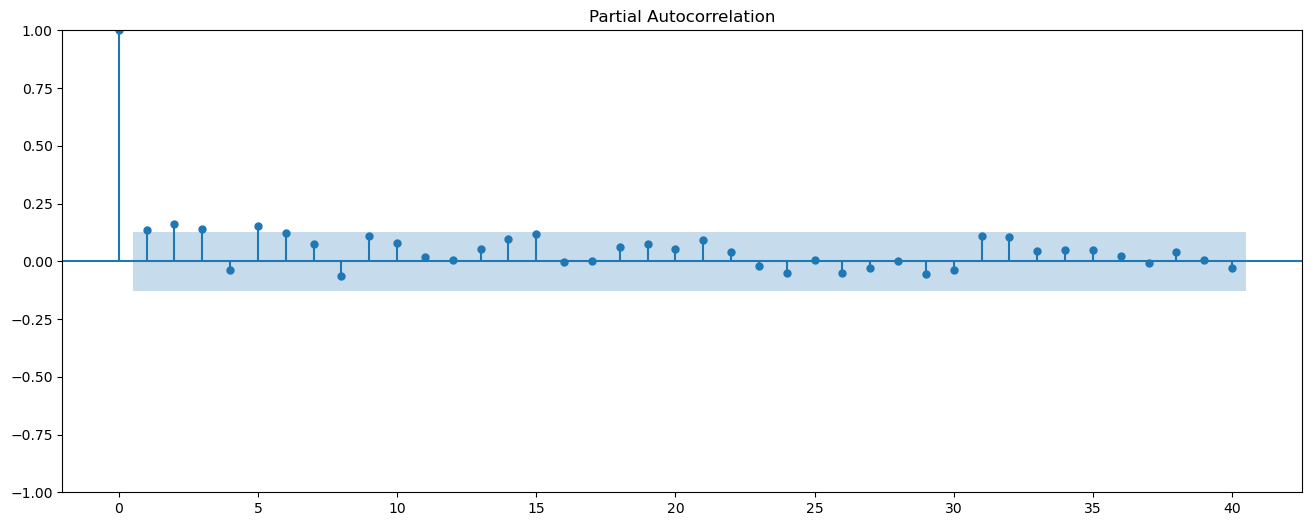

In [75]:
### PACF
sm.graphics.tsa.plot_pacf(df2['Y_D1'].values.squeeze(), lags=40)
plt.show()

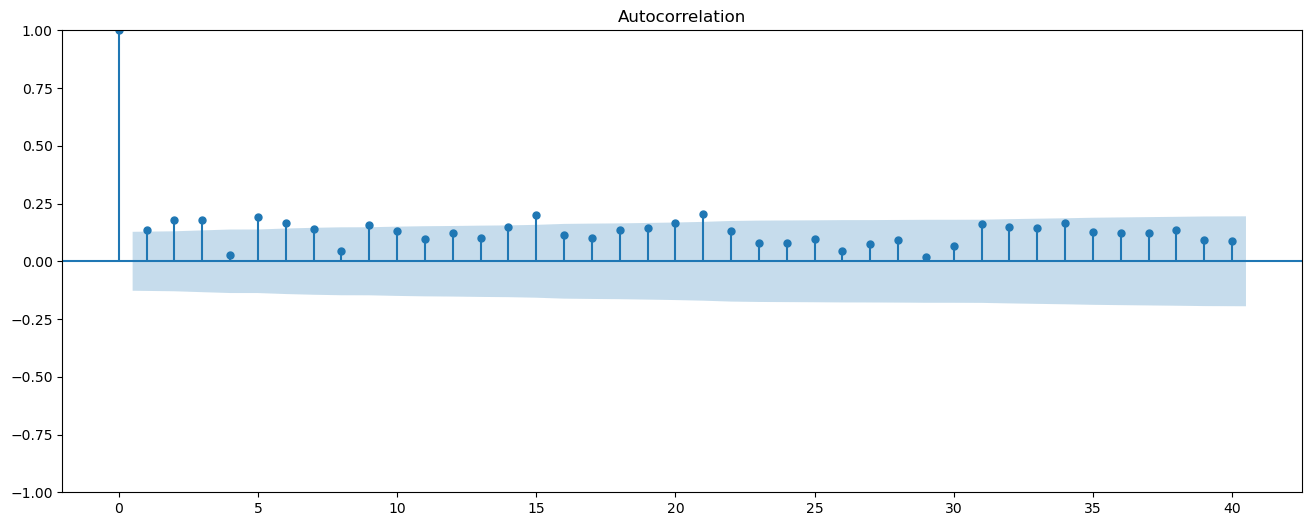

In [76]:
### ACF
sm.graphics.tsa.plot_acf(df2['Y_D1'].values.squeeze(), lags=40)
plt.show()

In [77]:
# to many convergence warnings
import warnings
warnings.filterwarnings('ignore')

# set up dataframe
df_AIC_BIC = pd.DataFrame(columns=['Model','AIC',"BIC"])

# filter for pre 2018
Y = df2['Y'][df2.index.year<=2018]
        
# set up combinations of results
tuple_list = [
    (0, 1, 0), (1, 1, 0), (0, 1, 1),
    (1, 1, 1), (2, 1, 1), (1, 1, 2),
    (2, 1, 2), (3, 1, 2), (2, 1, 3),
    (3, 1, 3), (4, 1, 3), (3, 1, 4),
    (4, 1, 4), (5, 1, 4), (4, 1, 5),
    (5, 1, 5), (6, 1, 5), (5, 1, 6),
    (6, 1, 6), (7, 1, 6), (6, 1, 7),
    (7, 1, 7)
]

# run for loop and exrtact BIC and AIC
for c in tuple_list:
    df_AIC_BIC = pd.concat([df_AIC_BIC,
                           pd.DataFrame({'Model' : [c],
                                         'AIC' : [ARIMA(Y, order= c).fit().aic],
                                         'BIC' : [ARIMA(Y, order= c).fit().bic]})])
    
df_AIC_BIC

,Model,AIC,BIC
0,"(0, 1, 0)",10602.08,10605.52
0,"(1, 1, 0)",10599.51,10606.38
0,"(0, 1, 1)",10590.17,10597.05
0,"(1, 1, 1)",10444.81,10455.12
0,"(2, 1, 1)",10446.61,10460.36
0,"(1, 1, 2)",10446.81,10460.57
0,"(2, 1, 2)",10448.47,10465.67
0,"(3, 1, 2)",10450.25,10470.88
0,"(2, 1, 3)",10450.24,10470.87
0,"(3, 1, 3)",10447.34,10471.41


In [78]:
df_AIC_BIC = df_AIC_BIC.reset_index(drop=True)

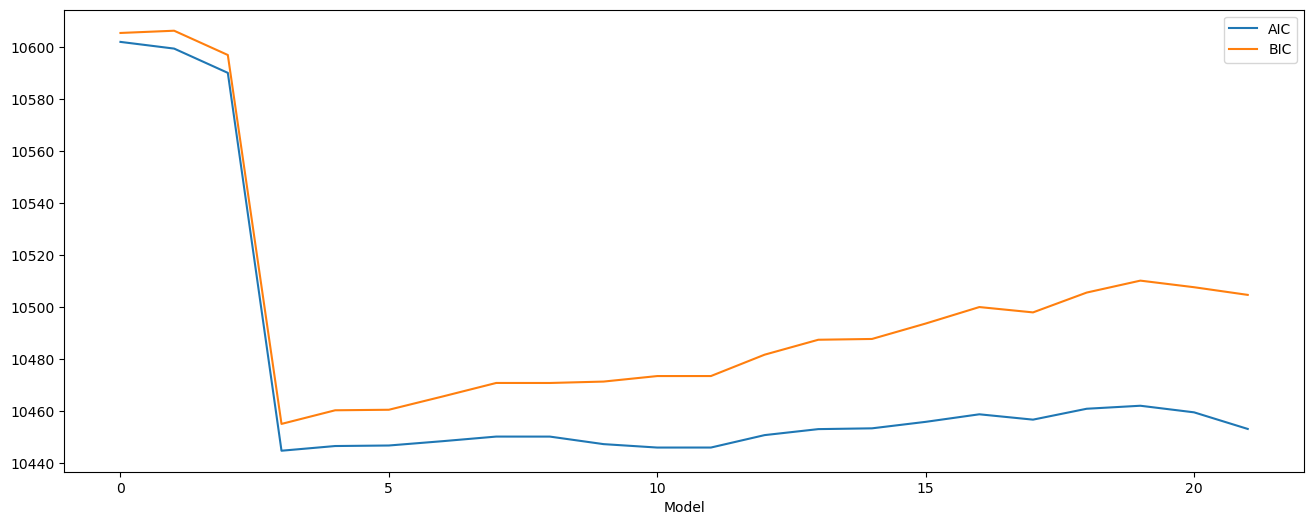

In [79]:
df_AIC_BIC['AIC'].plot()
df_AIC_BIC['BIC'].plot()
plt.xlabel('Model')
plt.legend()
plt.show()

In [80]:
res_ARIMA_111 = ARIMA(Y, order=(1,1,1)).fit()
print(res_ARIMA_111.summary())

                               SARIMAX Results                                
Dep. Variable:                      Y   No. Observations:                  231
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5219.403
Date:                Thu, 20 Aug 2026   AIC                          10444.807
Time:                        22:06:08   BIC                          10455.121
Sample:                             0   HQIC                         10448.967
                                - 231                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    569.714      0.000       0.997       1.003
ma.L1         -0.9991      0.056    -17.897      0.000      -1.109      -0.890
sigma2       3.15e+18        nan        nan        n

### (d). Ljung-Box Test for ARIMA(1,1,1)
For the selected and estimated model in (c), apply the Ljung and Box test to confirm that the model indeed is adequate. As a standard practice, remember to write down the null and alternative hypotheses, test statistics and the distribution it follows under the null, and the decision rule.

In [81]:
sm.stats.acorr_ljungbox(res_ARIMA_111.resid, return_df=False)

,lb_stat,lb_pvalue
1,0.10,0.75
2,0.10,0.95
3,0.19,0.98
4,0.22,0.99
5,0.22,1.00
6,0.23,1.00
7,0.26,1.00
8,0.60,1.00
9,0.85,1.00
10,0.88,1.00


### (e). 1 and 5 period ahead forecasts
Based on the ARIMA(p,d,q) model in (c), perform the 1-quarter ahead and 5-quarter ahead forecasting (point prediction) with 2018Q4 as the forecast origin, and respectively calculate the forecast residuals.

In [82]:
res_ARIMA_111.predict()

date
1961-01-04              0.00
1961-01-07    67693872652.26
1961-01-10    67165232963.16
1962-01-01    67887877896.22
1962-01-04    69751810306.21
                   ...      
2017-01-10   459437947169.58
2018-01-01   461840453143.71
2018-01-04   465967509332.76
2018-01-07   469629733868.35
2018-01-10   471112663658.52
Name: predicted_mean, Length: 231, dtype: float64

In [83]:
res_ARIMA_111.forecast(steps = 5)

231   471894961351.80
232   473649899214.73
233   475404813589.09
234   477159704475.21
235   478914571873.39
Name: predicted_mean, dtype: float64

In [84]:
df2['Y']

date
1961-01-04    65958000000.00
1961-01-07    65486000000.00
1961-01-10    66232000000.00
1962-01-01    68091000000.00
1962-01-04    69395000000.00
                   ...      
2019-01-01   472267000000.00
2019-01-04   475156000000.00
2019-01-07   477791000000.00
2019-01-10   480280000000.00
2020-01-01   478811000000.00
Name: Y, Length: 236, dtype: float64

In [85]:
resid = res_ARIMA_111.predict() - df2['Y']
print(resid)

date
1961-01-04   -65958000000.00
1961-01-07     2207872652.26
1961-01-10      933232963.16
1962-01-01     -203122103.78
1962-01-04      356810306.21
                   ...      
2019-01-01               NaN
2019-01-04               NaN
2019-01-07               NaN
2019-01-10               NaN
2020-01-01               NaN
Length: 236, dtype: float64


### (f). ARMA(1,1) forecast comparison
Now use the same $p$ and $q$ as in (c) and fit an $ARMA(p,q)$ model (that is, an $ARIMA(p,0,q)$ model, without considering the potential unit roots); perform the 1-quarter ahead and 5-quarter ahead forecasting (point prediction) with 2018Q4 as the forecast origin, and compare the forecast residuals to those in (e). What conclusion you may draw and briefly explain the difference in forecasting performance between the $ARMA(p,q)$ and $ARIMA(p,d,q)$.

In [86]:
ARMA_011 = ARIMA(Y, order=(1,0,1))
res_ARMA_111 = ARMA_011.fit()

print(res_ARMA_111.summary())

                               SARIMAX Results                                
Dep. Variable:                      Y   No. Observations:                  231
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5302.445
Date:                Thu, 20 Aug 2026   AIC                          10612.889
Time:                        22:06:08   BIC                          10626.659
Sample:                             0   HQIC                         10618.443
                                - 231                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.245e+11   7.12e-17   3.16e+27      0.000    2.25e+11    2.25e+11
ar.L1          0.9999      0.001   1764.645      0.000       0.999       1.001
ma.L1          0.3819      0.069      5.533      0.0

In [87]:
res_ARMA_111.predict()

date
1961-01-04   224544926406.93
1961-01-07    65969381451.03
1961-01-10    65343924568.39
1962-01-01    66583885332.70
1962-01-04    68683708683.64
                   ...      
2017-01-10   458912042888.84
2018-01-01   460521326268.50
2018-01-04   465596836258.89
2018-01-07   468708949581.64
2018-01-10   469571045169.41
Name: predicted_mean, Length: 231, dtype: float64

In [88]:
res_ARMA_111.forecast(steps = 5)

231   470327892572.53
232   470298496140.68
233   470269103224.74
234   470239713824.29
235   470210327938.90
Name: predicted_mean, dtype: float64

# Q3

The data set `ausunemp.csv` contains monthly data on the Australian unemployment rate, starting in January 1990.

### Load Data

In [89]:
data = pd.read_csv('ausunemp.csv')

In [90]:
data['Date'] = data['month']
data = data.set_index('Date')

In [91]:
data.head()

,month,unemp,m1,m2,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
Date,,,,,,,,,,,,,,
1990m1,1990m1,6.70,1,0,0,0,0,0,0,0,0,0,0,0
1990m2,1990m2,7.10,0,1,0,0,0,0,0,0,0,0,0,0
1990m3,1990m3,6.50,0,0,1,0,0,0,0,0,0,0,0,0
1990m4,1990m4,6.30,0,0,0,1,0,0,0,0,0,0,0,0
1990m5,1990m5,6.50,0,0,0,0,1,0,0,0,0,0,0,0


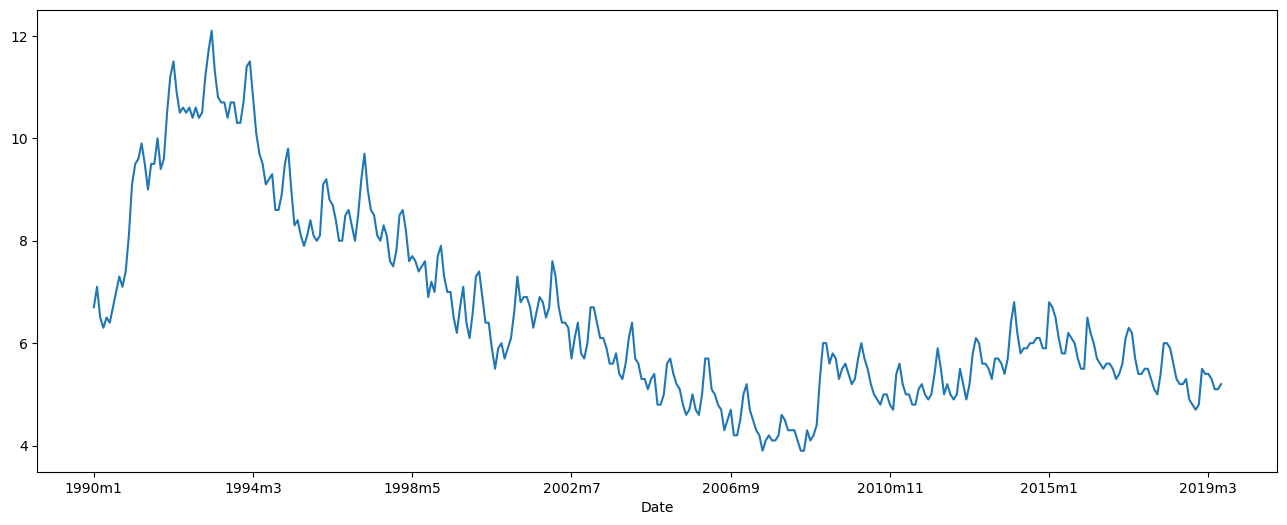

In [92]:
data['unemp'].plot()
plt.show()

Instead of all the below, you can use the `seasonal_decompose()` function from `statsmodel` as well:

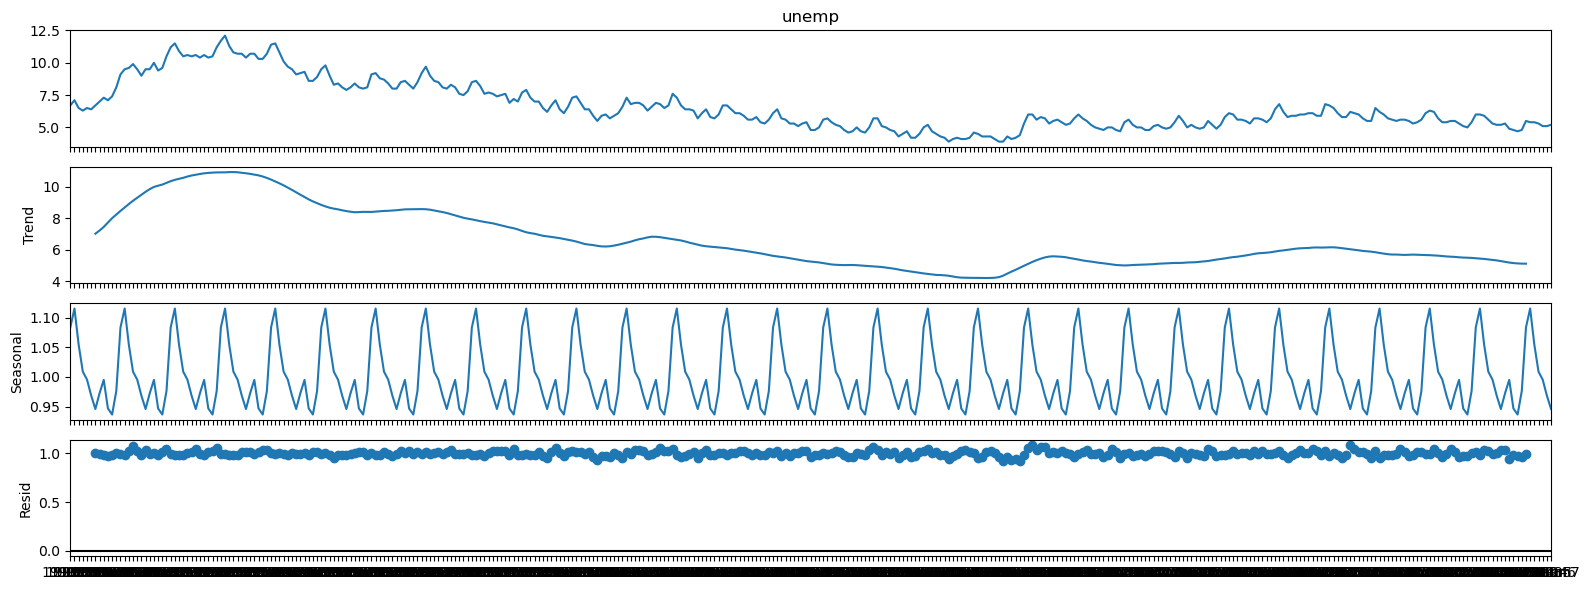

In [93]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(data['unemp'].dropna(), model = "multiplicative", period = 12)

decomp.plot();

However, below outlines a  nice approach to additive decomposition :)

### (a). Decompose the data into trend, seasonal, cyclical, and irregular components, and discuss your findings.

###### Calculate moving average

In [94]:
data['MA'] = data['unemp'].rolling(window=12, center = True).mean()

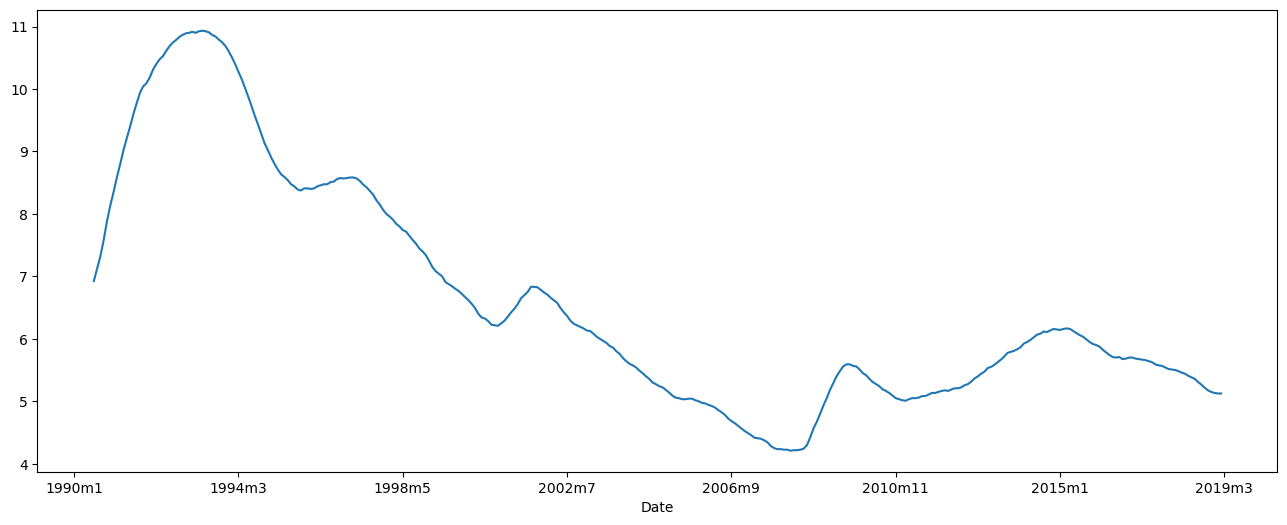

In [95]:
data['MA'].plot()
plt.show()

###### Compute CMA

In [96]:
data['CMA'] = data['MA'].rolling(window=2, center = True).mean().shift(-1)

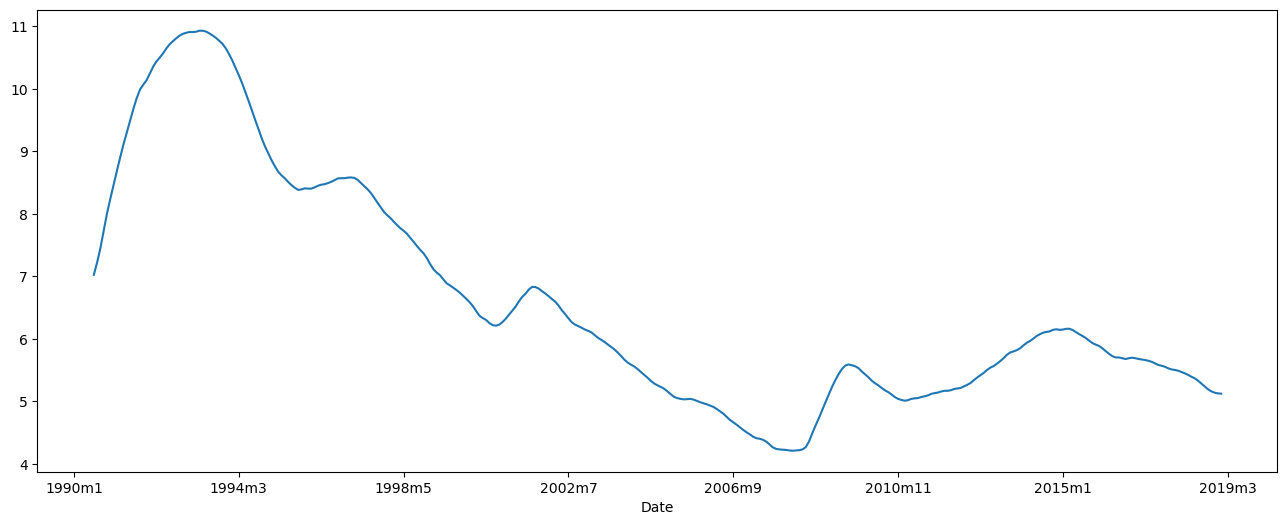

In [97]:
data['CMA'].plot()
plt.show()

###### Compute and Plot Y/CMA

In [98]:
data['unemp/CMA'] = data['unemp']/data['CMA']

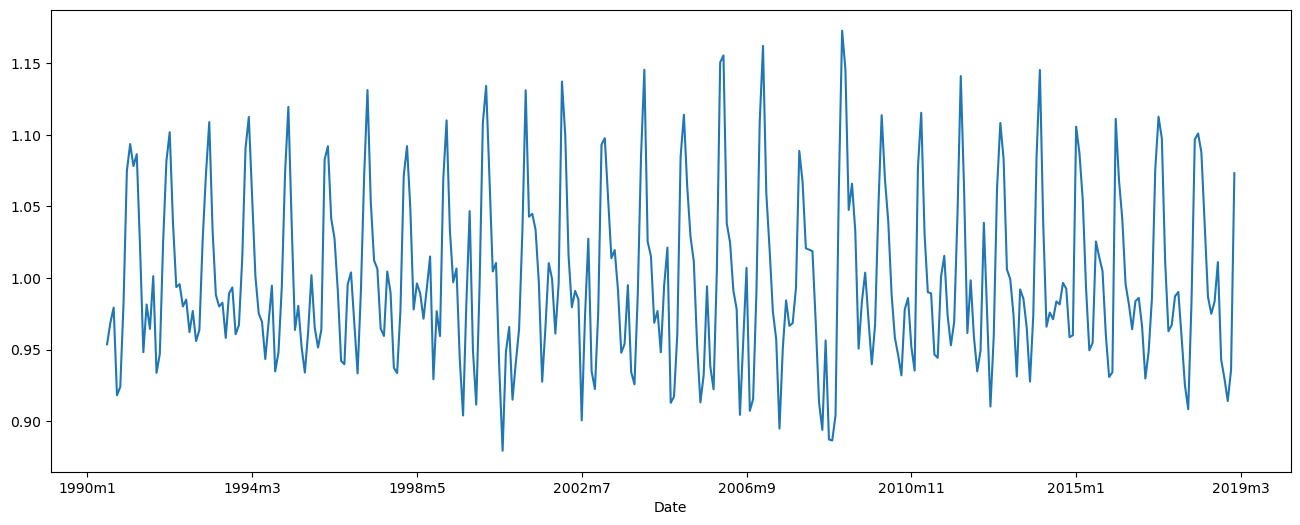

In [99]:
data['unemp/CMA'].plot()
plt.show()

###### Add 60 more periods for prediction

**(Note you can only add it here, not before nor afterwards otherwise there will be errors).**

In [100]:
L = 59  # how many zeros
i=0
while i<=L:
    i += 1
    last_date = df.index[-1] + pd.DateOffset(months=1)
    data.loc[last_date] = np.nan

###### Regress the variable on monthly dummies

In [101]:
model = sm.OLS(data['unemp/CMA'], 
               data[['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12']],
               missing = 'drop')
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              unemp/CMA   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     135.0
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          3.77e-115
Time:                        22:06:12   Log-Likelihood:                 769.83
No. Observations:                 343   AIC:                            -1516.
Df Residuals:                     331   BIC:                            -1470.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
m1             1.0835      0.005    223.489      0.0

###### Compute SN\bar based on prior regression

In [102]:
data['snbar'] = results.predict(data[['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12']])

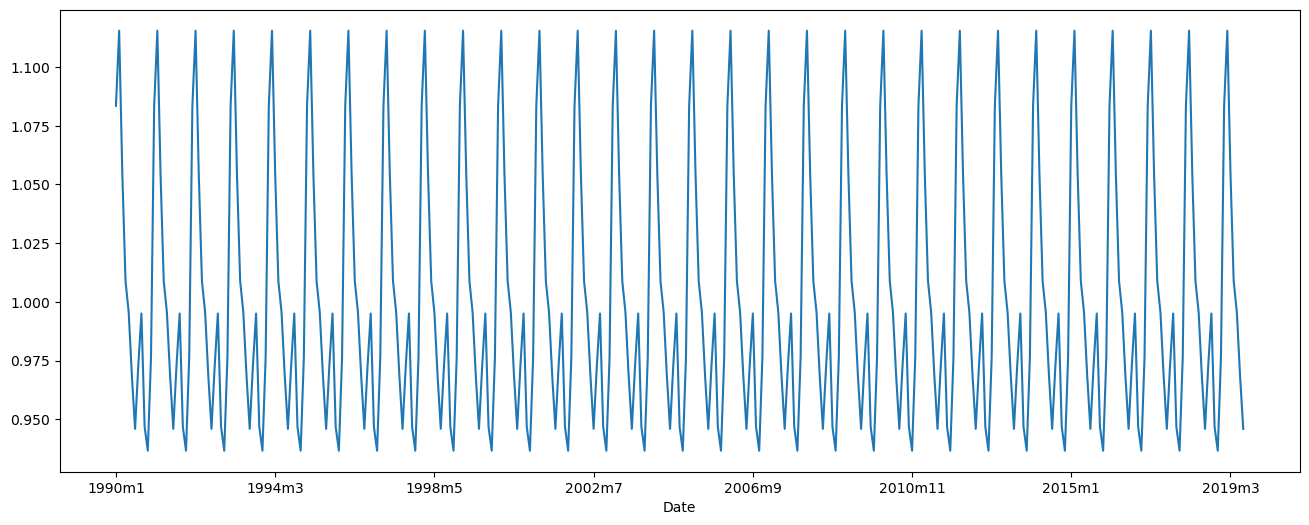

In [103]:
data['snbar'].plot()
plt.show()

###### careful: the regression trick that we used during the lecture to find the mean of the snbar doesn't work here, because there are more January's-July's than Augusts-Decembers in this data set. we can fix that by only regressing over the first year (or any year, really... or any period that includes equally many observations for each month)

In [104]:
df1 = data.head(12)

###### regressing all snbar with constant only is equivalent to compute the mean of snbar, both of which give you the same result. Hence, I replace the regression with a simple mean computataion to save computation load.

In [105]:
df1['snbar'].mean()

0.9999358564198793

In [106]:
data['sn'] = data['snbar']/df1['snbar'].mean()

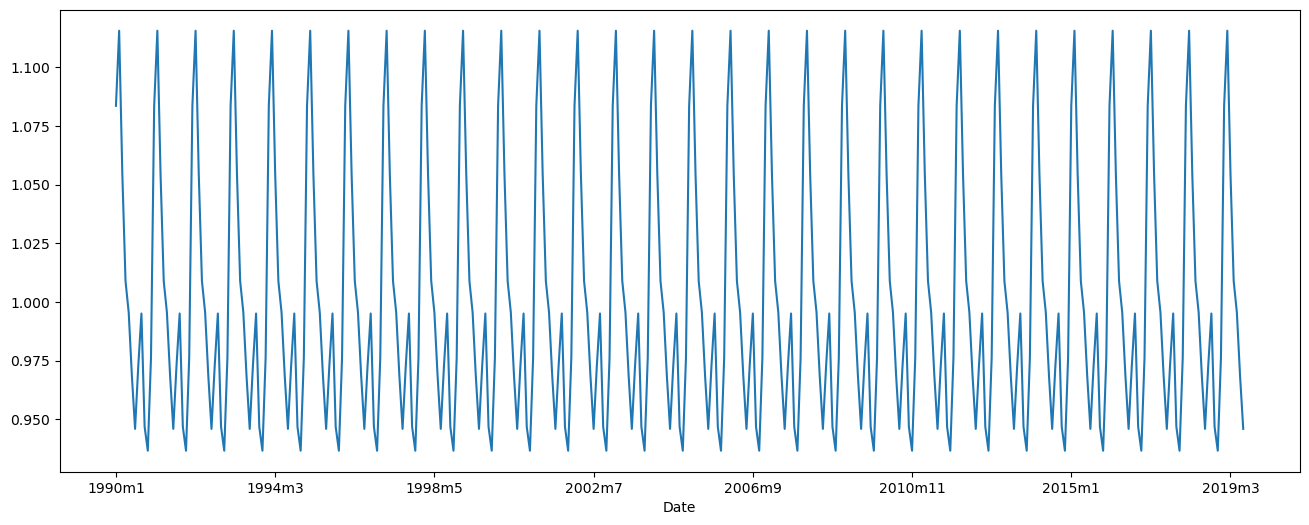

In [107]:
data['sn'].plot()
plt.show()

###### Computer and plot the d_t, deseasonalised signal

In [108]:
data['d'] = data['unemp']/data['sn']

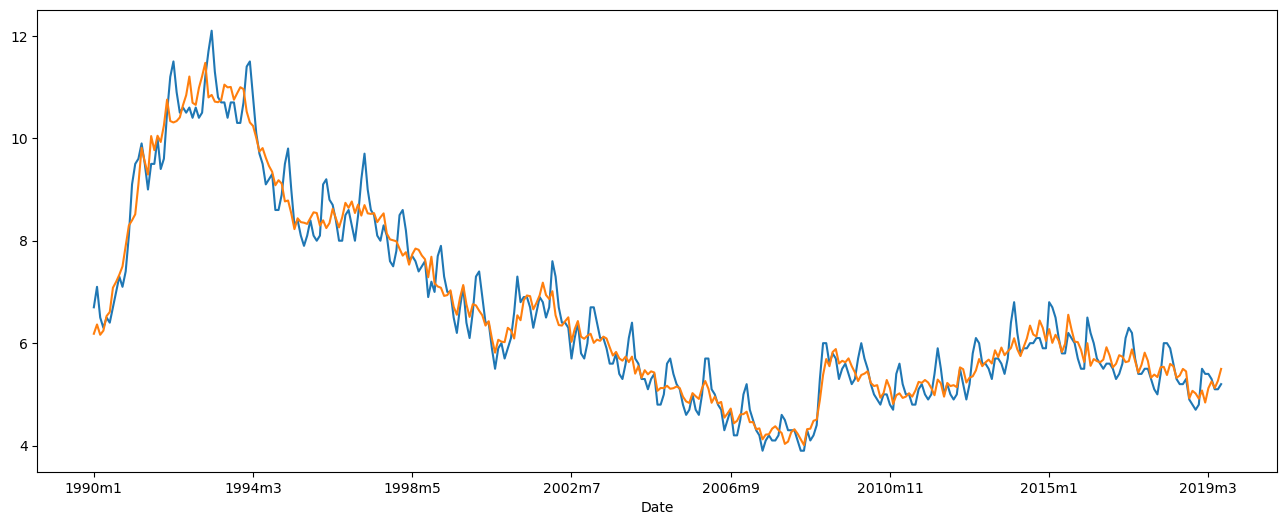

In [109]:
data['unemp'].plot()
data['d'].plot()
plt.show()

###### lets detrend by regressing the deseasonalised signal to the polynomial of t

In [110]:
data['t'] = np.arange(len(data))
data['t2'] = np.power(data['t'],2)
data['t3'] = np.power(data['t'],3)
data['t4'] = np.power(data['t'],4)

In [111]:
X = data[['t','t2','t3','t4']]
X = sm.add_constant(X)

model1= sm.OLS(data['d'], X, missing='drop')
results1 = model1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                      d   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     770.7
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          4.73e-172
Time:                        22:06:13   Log-Likelihood:                -314.48
No. Observations:                 355   AIC:                             639.0
Df Residuals:                     350   BIC:                             658.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7027      0.154     49.948      0.0

##### Compute the trend signal TR

In [112]:
### The OLS estimators have got stuck at a local minimum and not the global minimum. Thus the estimatrs for tr are wrong
data['tr'] = results1.predict(X)

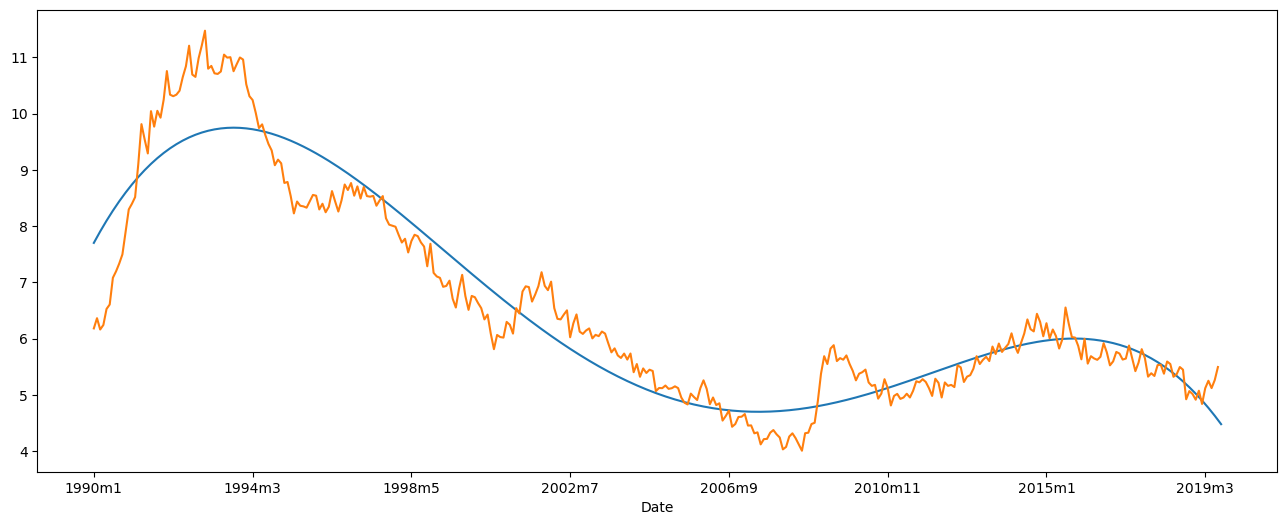

In [113]:
data['tr'].plot()
data['d'].plot()
plt.show()

In [114]:
data['trsn'] = data['tr'] * data['sn']

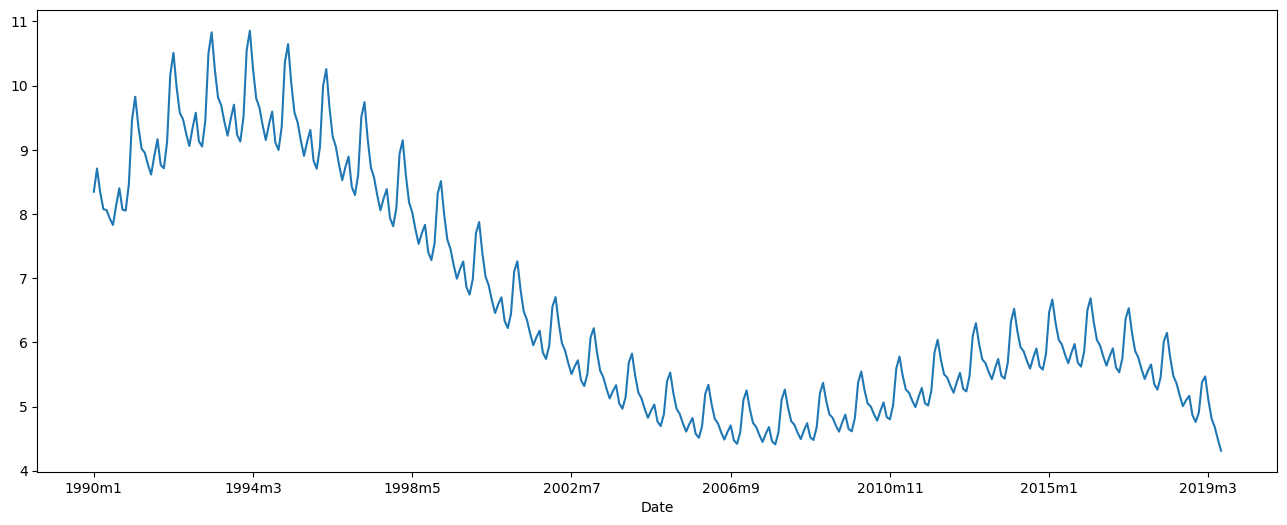

In [115]:
data['trsn'].plot()
plt.show()

#### (b). Use your decomposition to forecast the behaviour of the unemployment rate over the next five years.
Construcitng prediction intervals where prtsed is the prediction standard error in sample with lower and upper bounds

In [116]:
prstd, iv_l, iv_u= wls_prediction_std(results1)

###### However, unlike stata, statsmodel package cannot compute the prediction standard error for out-of-sample data (2019-08-01 to 2024-07-01). Hence, I have to manually compute it myself. The following computation is based on the formula in the book "Element of Statistcal Learning".

In [117]:
x_new  = X[-60:]
x_mat  = X[:355]

sigma2_est = sum(results1.resid**2) / (len(x_mat) - 5)

# Calculate the prediction SE:
y_pred_se = np.linalg.inv(np.dot(np.transpose(x_mat), x_mat))
y_pred_se = np.dot(np.dot(x_mat, y_pred_se), np.transpose(x_mat))
y_pred_se = np.identity(len(x_mat)) + y_pred_se
y_pred_se = sigma2_est * y_pred_se
y_pred_se = np.sqrt(np.diag(y_pred_se))

###### the prediction standard error for out-of-sample data (2019-08-01 to 2024-07-01).

###### combining the in-sample and out-of-sample prediction standard error, let's costruct the prediction interval for TR and the prediction interval for TR. SN using confidence level 0.95, for both in-sample and out-of-sample data

In [118]:
len(prstd)

355

In [119]:
prstd, iv_l, iv_u = wls_prediction_std(results1)

data['se'] = np.concatenate(([1],y_pred_se))
#data['se'] = y_pred_se
data['tr_lo_95'] = data['tr'] - t.ppf(0.975, 350) * data['se']
data['tr_hi_95'] = data['tr'] + t.ppf(0.975, 350) * data['se']
data['trsn_lo_95'] = data['trsn'] - t.ppf(0.975, 350) * data['se']
data['trsn_hi_95'] = data['trsn'] + t.ppf(0.975, 350) * data['se']

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356 entries, 1990m1 to 2020-02-01 00:00:00
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month       355 non-null    object 
 1   unemp       355 non-null    float64
 2   m1          355 non-null    float64
 3   m2          355 non-null    float64
 4   m3          355 non-null    float64
 5   m4          355 non-null    float64
 6   m5          355 non-null    float64
 7   m6          355 non-null    float64
 8   m7          355 non-null    float64
 9   m8          355 non-null    float64
 10  m9          355 non-null    float64
 11  m10         355 non-null    float64
 12  m11         355 non-null    float64
 13  m12         355 non-null    float64
 14  MA          344 non-null    float64
 15  CMA         343 non-null    float64
 16  unemp/CMA   343 non-null    float64
 17  snbar       355 non-null    float64
 18  sn          355 non-null    float64
 19  d           3

In [121]:
data

,month,unemp,m1,m2,m3,m4,m5,m6,m7,m8,...,t2,t3,t4,tr,trsn,se,tr_lo_95,tr_hi_95,trsn_lo_95,trsn_hi_95
Date,,,,,,,,,,,,,,,,,,,,,
1990m1,1990m1,6.70,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0,0,0,7.70,8.35,1.00,5.74,9.67,6.38,10.31
1990m2,1990m2,7.10,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1,1,1,7.81,8.71,0.61,6.60,9.01,7.51,9.91
1990m3,1990m3,6.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,4,8,16,7.91,8.34,0.61,6.71,9.10,7.14,9.54
1990m4,1990m4,6.30,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,9,27,81,8.00,8.07,0.61,6.81,9.20,6.88,9.27
1990m5,1990m5,6.50,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,16,64,256,8.10,8.06,0.61,6.90,9.29,6.87,9.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019m4,2019m4,5.30,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,123201,43243551,15178486401,4.77,4.81,0.61,3.58,5.96,3.62,6.01
2019m5,2019m5,5.10,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,123904,43614208,15352201216,4.70,4.68,0.61,3.51,5.90,3.49,5.88
2019m6,2019m6,5.10,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,124609,43986977,15527402881,4.63,4.49,0.61,3.44,5.83,3.29,5.68


In [122]:
data.iloc[:,30]

Date
1990m1                10.31
1990m2                 9.91
1990m3                 9.54
1990m4                 9.27
1990m5                 9.25
                       ... 
2019m4                 6.01
2019m5                 5.88
2019m6                 5.68
2019m7                 5.51
2020-02-01 00:00:00     NaN
Name: trsn_hi_95, Length: 356, dtype: float64

###### Scatter plot deseason data, line plot TR, and corresponding in-sample prediction interval

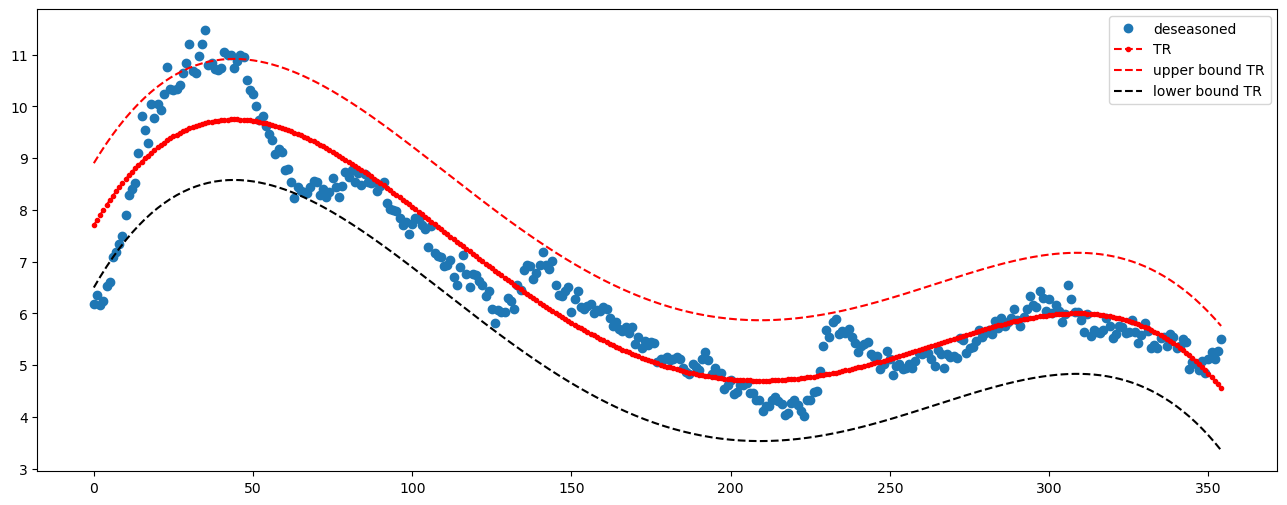

In [123]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(data['t'][:355], data['d'][:355], 'o', label="deseasoned")
ax.plot(data['t'][:355], results1.fittedvalues, 'r--.', label="TR")
ax.plot(data['t'][:355], iv_u, 'r--', label="upper bound TR")
ax.plot(data['t'][:355], iv_l, 'k--', label="lower bound TR")
ax.legend(loc='best');

##### scatter plot of deseasoned datya, line plot TR, and corresponding in-sample PI

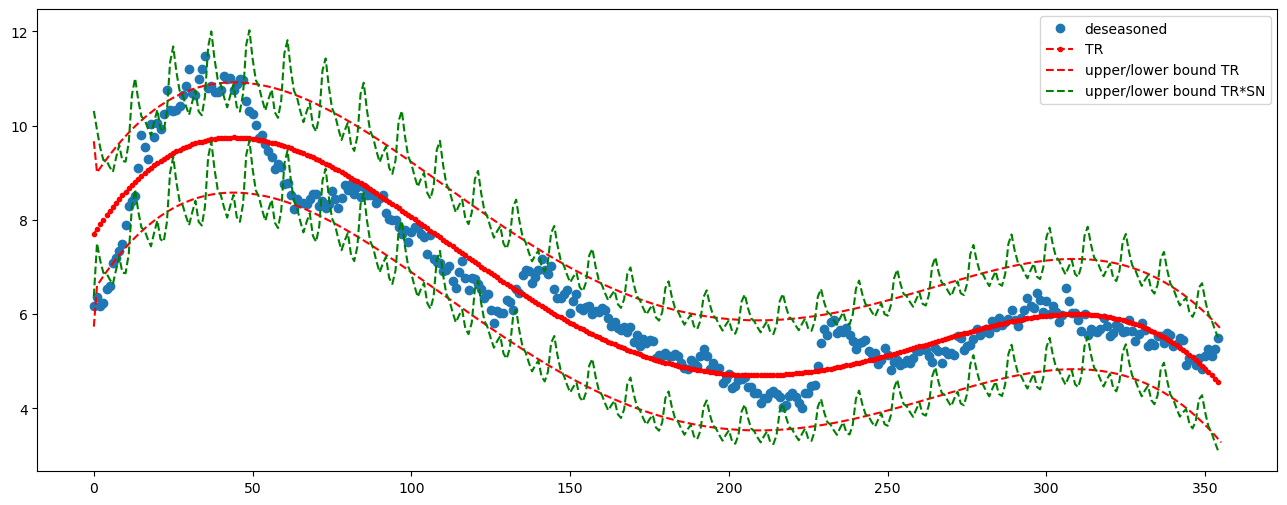

In [124]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(data['t'][:355], data['d'][:355], 'o', label="deseasoned")
ax.plot(data['t'][:355], results1.fittedvalues, 'r--.', label="TR")
ax.plot(data['t'], data['tr_hi_95'], 'r--', label="upper/lower bound TR")
ax.plot(data['t'], data['tr_lo_95'], 'r--')
ax.plot(data['t'], data['trsn_hi_95'], 'g--', label="upper/lower bound TR*SN")
ax.plot(data['t'], data['trsn_lo_95'], 'g--')
ax.legend(loc='best');

In [125]:
### cylce times irregular
data['clir'] = data['d'] / data['tr']
data['clir'].head(10)

Date
1990m1    0.80
1990m2    0.82
1990m3    0.78
1990m4    0.78
1990m5    0.81
1990m6    0.81
1990m7    0.86
1990m8    0.86
1990m9    0.87
1990m10   0.88
Name: clir, dtype: float64

In [126]:
### Moving average
data['cl']      = data['clir'].rolling(window=3, center=True).mean()
data['cl'][0]   = (2*data['clir'][0]   + data['clir'][1]  )/3
data['cl'][354] = (2*data['clir'][354] + data['clir'][353])/3
data['cl'].head(10)

Date
1990m1    0.81
1990m2    0.80
1990m3    0.79
1990m4    0.79
1990m5    0.80
1990m6    0.82
1990m7    0.84
1990m8    0.86
1990m9    0.87
1990m10   0.89
Name: cl, dtype: float64

In [127]:
### replace NA of CL with 1
data['cl'].iloc[-60:] = 1
data['cl'].tail(10)

Date
2018m11               1.00
2018m12               1.00
2019m1                1.00
2019m2                1.00
2019m3                1.00
2019m4                1.00
2019m5                1.00
2019m6                1.00
2019m7                1.00
2020-02-01 00:00:00   1.00
Name: cl, dtype: float64

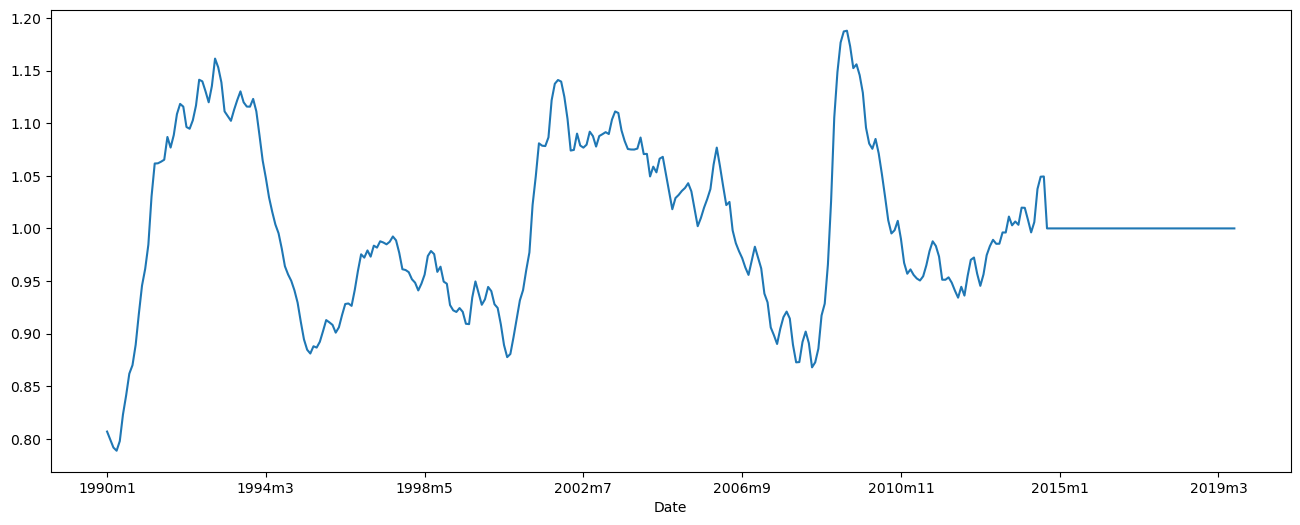

In [128]:
data['cl'].plot()
plt.show()

In [129]:
### compute IR
data['ir'] =data['clir']/data['cl']
data['ir'].tail(10)

Date
2018m11               0.99
2018m12               0.98
2019m1                1.02
2019m2                0.99
2019m3                1.06
2019m4                1.10
2019m5                1.09
2019m6                1.14
2019m7                1.21
2020-02-01 00:00:00    NaN
Name: ir, dtype: float64

In [130]:
data['trsncl']= data['trsn'] * data['cl']
data['trsncl'].tail(10)

Date
2018m11               4.76
2018m12               4.90
2019m1                5.38
2019m2                5.47
2019m3                5.10
2019m4                4.81
2019m5                4.68
2019m6                4.49
2019m7                4.31
2020-02-01 00:00:00    NaN
Name: trsncl, dtype: float64

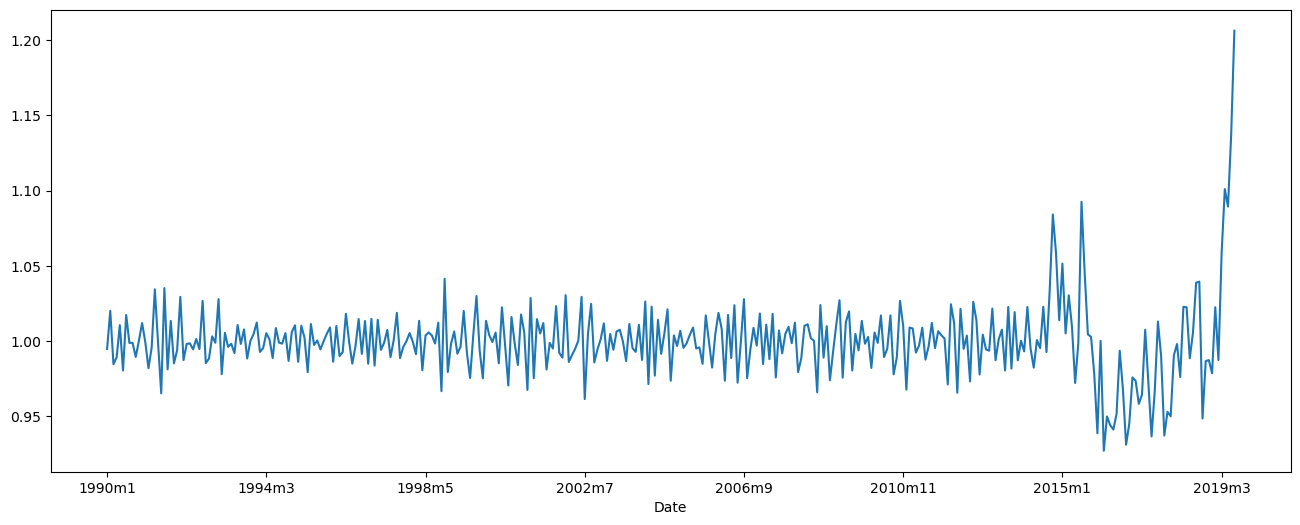

In [131]:
### plot IR
data['ir'].plot()
plt.show()

### Now let's plot everything together (in-sample)

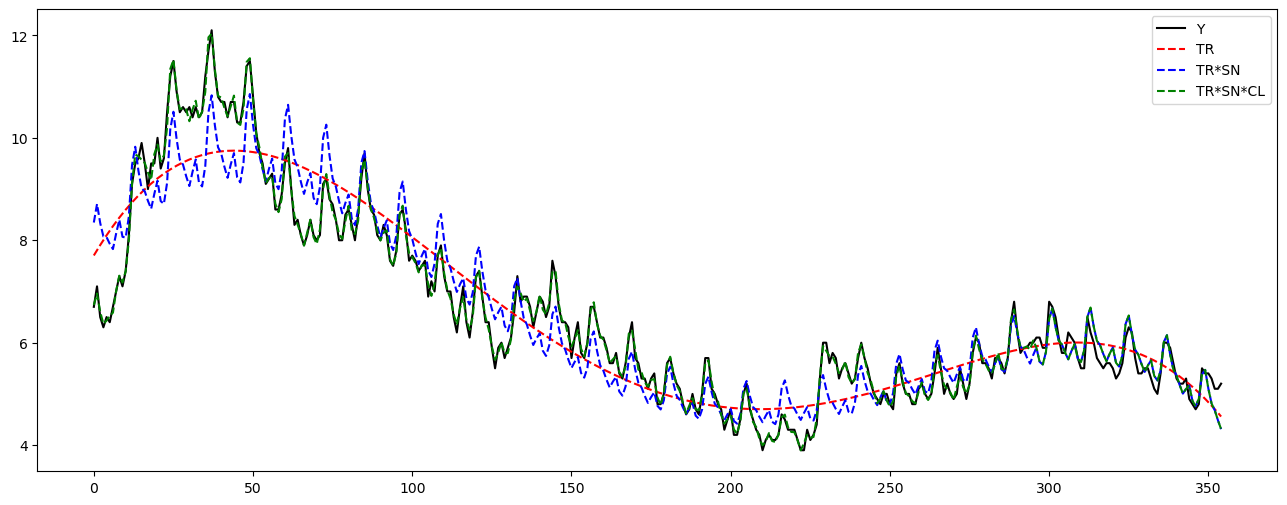

In [132]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(data['t'][:355], data['unemp'][:355]     , 'k'  , label="Y")
ax.plot(data['t'][:355], data['tr'][:355]    , 'r--', label="TR")
ax.plot(data['t'][:355], data['trsn'][:355]  , 'b--', label="TR*SN")
ax.plot(data['t'][:355], data['trsncl'][:355], 'g--', label="TR*SN*CL")
ax.legend(loc='best');

plt.show()

### Now let's plot each component (in-sample)

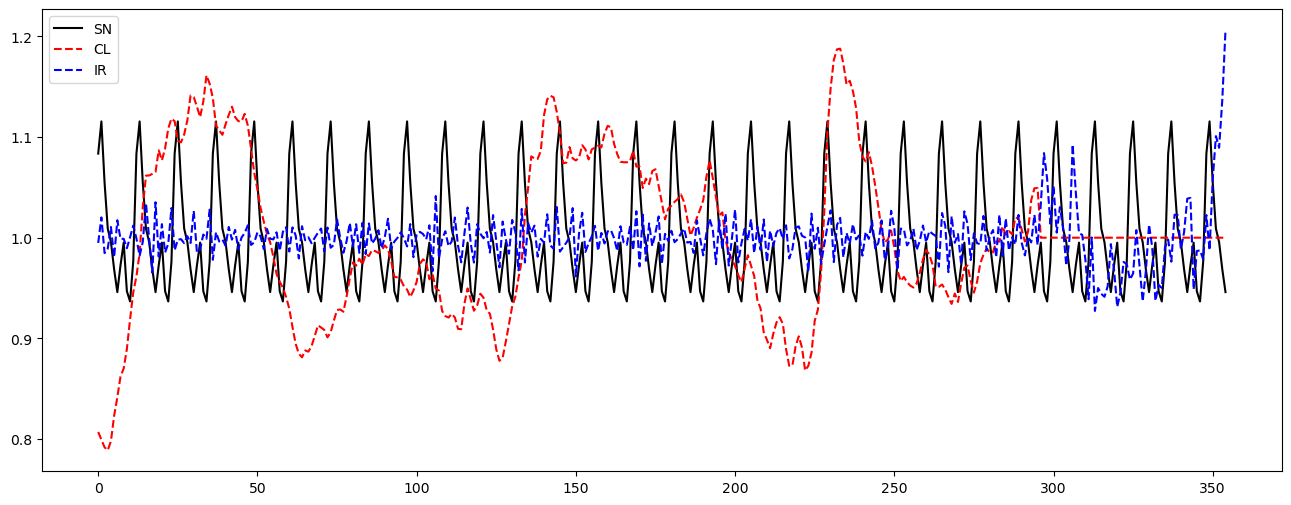

In [133]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(data['t'][:355], data['sn'][:355], 'k'  , label="SN")
ax.plot(data['t'][:355], data['cl'][:355], 'r--', label="CL")
ax.plot(data['t'][:355], data['ir'][:355], 'b--', label="IR")
ax.legend(loc='best');

plt.show()

### prediction plot (in-sample and out-of-sample)

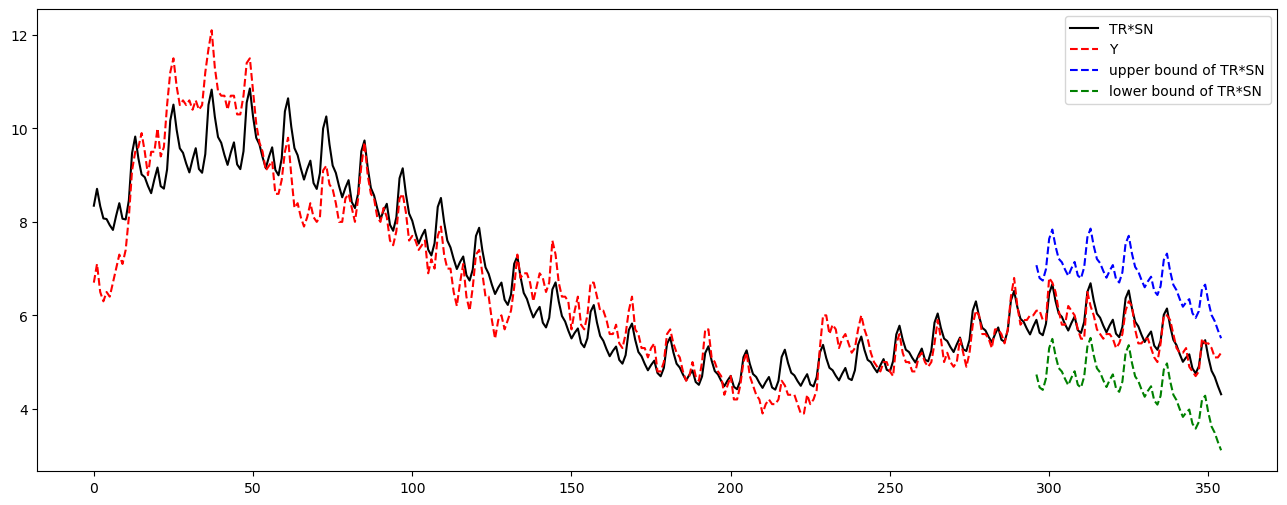

In [134]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(data['t'], data['trsn'], 'k'  , label="TR*SN")
ax.plot(data['t'], data['unemp']   , 'r--', label="Y")

ax.plot(data['t'][-60:], data['trsn_hi_95'][-60:], 'b--', label="upper bound of TR*SN")
ax.plot(data['t'][-60:], data['trsn_lo_95'][-60:], 'g--', label="lower bound of TR*SN")
ax.legend(loc='best');

plt.show()